# Visualization - "Colour Without Sight: How Visually Impaired Individuals Engage With Colour" 

Author: Nina Vreugdenhil 
Affiliation: University of Amsterdam 
Description: visualizes the data from the questionnaire about colour experiences and associations that was completed by 46 blind individuals

### Load packages

In [50]:
# Load packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.stats import chi2_contingency
from pathlib import Path

### Load and filter data

In [51]:
# Set parameters for plotting
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'pdf.fonttype':42})
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False 

In [52]:
# Directory this notebook is located in (works as long as Jupyter is started from this folder)
notebook_dir = Path.cwd()

# Path to the data, relative to the notebook directory
loc_data = notebook_dir / "Processed_Data" / "data_questionnaire_filtered.csv"

# Folder to save figures in
fig_folder = notebook_dir / "Figuren_Vragenlijst"
fig_folder.mkdir(exist_ok=True)  # creates the folder if it doesn't exist yet

In [53]:
# Read in data
df = pd.read_csv(loc_data, sep = ",") 

In [54]:
df_totaalblind = df[df["Beschrijving zicht "] == "Totaal blind: ik neem helemaal geen licht waar"]
df_max2procent = df[df["Beschrijving zicht "] == "Mijn gezichtsscherpte is maximaal 2%, ik kan opgestoken vingers tellen op 1 meter afstand."]
df_2_5procent = df[df["Beschrijving zicht "] == "Mijn gezichtsscherpte is tussen de 2% en 5%, ik zie licht en de omtrek van mensen en voorwerpen, maar mijn visuele beperking heeft grote invloed op mijn leven."]
df_anders = df[df["Beschrijving zicht "] == "Anders, namelijk:"]

df_totaalblind_CB = df_totaalblind[df_totaalblind["Leeftijd zicht nu"] == 0] # Create dataframe for congenitally totally blind participants
df_totaalblind_LB = df_totaalblind[df_totaalblind["Leeftijd zicht nu"] > 0] # Create dataframe for non-congenitally totally blind participants

### Crossmodal correspondences

#### Plot associations for congenitally totally blind individuals 

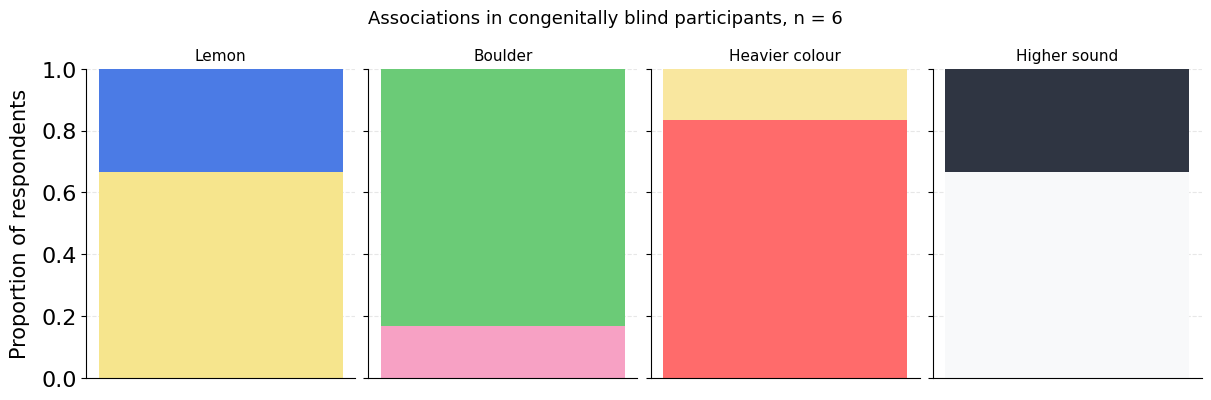

In [55]:
# Prepare the data
# Make a copy of the original dataframe so we don't accidentally modify it
df = df_totaalblind_CB.copy()

# Strip whitespace from column names (e.g. 'Citroen ' -> 'Citroen')
df.columns = df.columns.str.strip()

# The columns (questions) we want to plot
cols = ["Citroen", "Kei", "Kleur zwaarder", "Q47"]

# For each column: the order in which the answer categories should be shown
order = {
    "Citroen": ["Snel", "Langzaam"],
    "Kei": ["Zoet", "Zuur"],
    "Kleur zwaarder": ["Rood", "Geel"],
    "Q47": ["Wit", "Zwart"],
}

# Colours per answer category, per column
# (each sub-dict maps an answer option to a hex colour)
COLOR_MAPS = {
    "Citroen": {        # yellow / blue
        "Snel": "#F6E58D",     # soft yellow
        "Langzaam": "#4B7BE5"  # soft blue
    },
    "Kei": {             # pink / green
        "Zoet": "#F7A1C4",     # soft pink
        "Zuur": "#6BCB77"      # soft green
    },
    "Kleur zwaarder": {  # red / yellow
        "Rood": "#FF6B6B",     # soft red
        "Geel": "#F9E79F"      # soft yellow
    },
    "Q47": {             # white / black
        "Wit": "#F8F9FA",      # off-white
        "Zwart": "#2F3542"     # very dark grey, almost black
    },
}

# Clean (English) titles for each subplot, per column name
titles = {
    "Citroen": "Lemon",
    "Kei": "Boulder",
    "Kleur zwaarder": "Heavier colour",
    "Q47": "Higher sound",
}

# Set up the figure
# Create a figure with 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 3.5),
    sharey=True,
    constrained_layout=True  # <<< important: prevents overlapping labels/titles
)

# Loop over each axis (subplot) together with its corresponding column name
for ax, col in zip(axes, cols):
    # Get the column values, drop missing values, and make everything clean strings
    s = df[col].dropna().astype(str).str.strip()

    # Count how often each value occurs (absolute counts and as a proportion/percentage)
    counts_abs = s.value_counts()
    counts = s.value_counts(normalize=True)

    # Make sure the categories are in the desired order (and fill in any missing
    # categories with 0, so the bar is always built up consistently)
    if col in order:
        counts = counts.reindex(order[col], fill_value=0)
        counts_abs = counts_abs.reindex(order[col], fill_value=0)

    # Starting point (bottom) of the stacked bar
    bottom = 0.0

    # Draw each category as a separate segment stacked on top of the previous one
    for level, proportion in zip(counts.index, counts.values):
        if proportion == 0:
            continue  # skip empty categories, otherwise you'd get a sliver at 0

        ax.bar(
            0,                          # x-position: always 0 (only 1 bar per subplot)
            proportion,                 # height of this segment = proportion for this category
            bottom=bottom,              # start this segment where the previous one ended
            width=0.6,
            color=COLOR_MAPS[col].get(level, "#CCCCCC"),  # colour, or grey if unknown
            edgecolor="none",
        )
        bottom += proportion  # raise the "bottom" for the next segment

    # Per subplot axis settings
    ax.set_ylim(0, 1)       # y-axis runs from 0 to 1 (proportions)
    ax.set_xticks([])       # no x-axis ticks needed (there's only one bar)
    ax.set_xlabel("")
    ax.set_title(titles[col], fontsize=11)

    # Subtle horizontal gridlines, drawn behind the bars
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    # Remove top and right spines for a cleaner look
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents", fontsize=15, labelpad=8)

# Title above the whole figure, including the number of respondents (n)
fig.suptitle(
    f"Associations in congenitally blind participants, n = {len(df)}",
    y=1.10,
    fontsize=13,
)

# Save the figure
# Save the figure as both PDF and PNG in the specified folder
fig.savefig(fig_folder / "associationsinCB.pdf", bbox_inches="tight")
fig.savefig(fig_folder / "associationsinCB.png", bbox_inches="tight")

plt.show()

#### Plot associations for non-congenitally totally blind participants

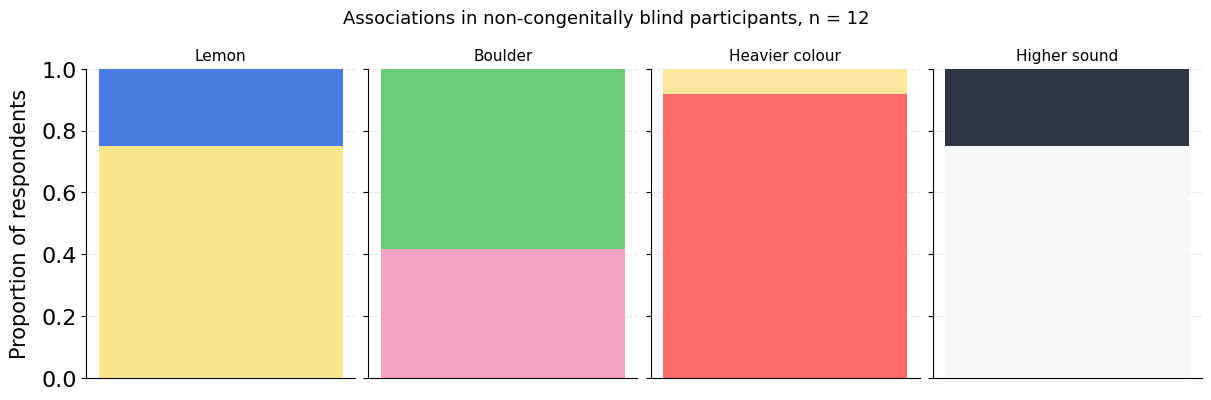

In [56]:
# Prepare the data
# Make a copy of the original dataframe so we don't accidentally modify it
df = df_totaalblind_LB.copy()

# Strip whitespace from column names (e.g. 'Citroen ' -> 'Citroen')
df.columns = df.columns.str.strip()

# The columns (questions) we want to plot
cols = ["Citroen", "Kei", "Kleur zwaarder", "Q47"]

# For each column: the order in which the answer categories should be shown
order = {
    "Citroen": ["Snel", "Langzaam"],
    "Kei": ["Zoet", "Zuur"],
    "Kleur zwaarder": ["Rood", "Geel"],
    "Q47": ["Wit", "Zwart"],
}

# Colours per answer category, per column
# (each sub-dict maps an answer option to a hex colour)
COLOR_MAPS = {
    "Citroen": {        # yellow / blue
        "Snel": "#F6E58D",     # soft yellow
        "Langzaam": "#4B7BE5"  # soft blue
    },
    "Kei": {             # pink / green
        "Zoet": "#F7A1C4",     # soft pink
        "Zuur": "#6BCB77"      # soft green
    },
    "Kleur zwaarder": {  # red / yellow
        "Rood": "#FF6B6B",     # soft red
        "Geel": "#F9E79F"      # soft yellow
    },
    "Q47": {             # white / black
        "Wit": "#F8F9FA",      # off-white
        "Zwart": "#2F3542"     # very dark grey, almost black
    },
}

# Clean (English) titles for each subplot, per column name
titles = {
    "Citroen": "Lemon",
    "Kei": "Boulder",
    "Kleur zwaarder": "Heavier colour",
    "Q47": "Higher sound",
}

# Set up the figure
# Create a figure with 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 3.5),
    sharey=True,
    constrained_layout=True  # <<< important: prevents overlapping labels/titles
)

# Loop over each axis (subplot) together with its corresponding column name
for ax, col in zip(axes, cols):
    # Get the column values, drop missing values, and make everything clean strings
    s = df[col].dropna().astype(str).str.strip()

    # Count how often each value occurs (absolute counts and as a proportion/percentage)
    counts_abs = s.value_counts()
    counts = s.value_counts(normalize=True)

    # Make sure the categories are in the desired order (and fill in any missing
    # categories with 0, so the bar is always built up consistently)
    if col in order:
        counts = counts.reindex(order[col], fill_value=0)
        counts_abs = counts_abs.reindex(order[col], fill_value=0)

    # Starting point (bottom) of the stacked bar
    bottom = 0.0

    # Draw each category as a separate segment stacked on top of the previous one
    for level, proportion in zip(counts.index, counts.values):
        if proportion == 0:
            continue  # skip empty categories, otherwise you'd get a sliver at 0

        ax.bar(
            0,                          # x-position: always 0 (only 1 bar per subplot)
            proportion,                 # height of this segment = proportion for this category
            bottom=bottom,              # start this segment where the previous one ended
            width=0.6,
            color=COLOR_MAPS[col].get(level, "#CCCCCC"),  # colour, or grey if unknown
            edgecolor="none",
        )
        bottom += proportion  # raise the "bottom" for the next segment

    # Per subplot axis settings
    ax.set_ylim(0, 1)       # y-axis runs from 0 to 1 (proportions)
    ax.set_xticks([])       # no x-axis ticks needed (there's only one bar)
    ax.set_xlabel("")
    ax.set_title(titles[col], fontsize=11)

    # Subtle horizontal gridlines, drawn behind the bars
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    # Remove top and right spines for a cleaner look
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents", fontsize=15, labelpad=8)

# Title above the whole figure, including the number of respondents (n)
fig.suptitle(
    f"Associations in non-congenitally blind participants, n = {len(df)}",
    y=1.10,
    fontsize=13,
)

# Save the figure
# Save the figure as both PDF and PNG in the specified folder
fig.savefig(fig_folder / "associationsinLB.pdf", bbox_inches="tight")
fig.savefig(fig_folder / "associationsinLB.png", bbox_inches="tight")

plt.show()

### Colour in language

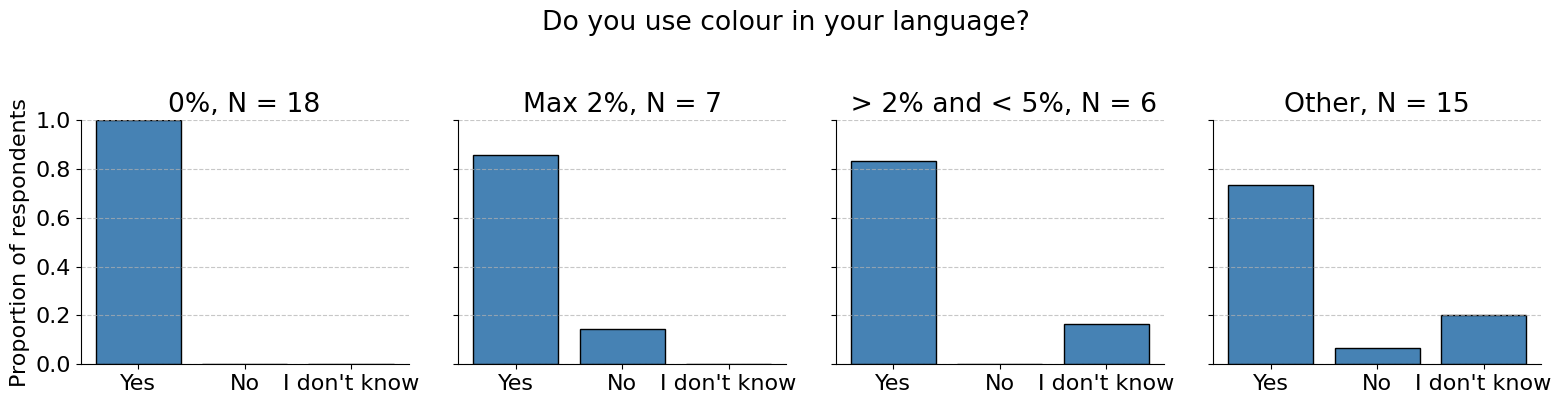

In [57]:
# Labels as they appear in the data (Dutch)
categories_nl = ["Ja", "Nee", "Weet ik niet"]

# Labels for the axis (English)
categories_en = ["Yes", "No", "I don't know"]

# Create 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(1, 4, figsize=(16,4), sharey=True)

# Loop over each subplot together with its dataset and title
for ax, data, title in zip(
    axes,
    [df_totaalblind, df_max2procent, df_2_5procent, df_anders],
    ["0%", "Max 2%", " > 2% and < 5%", "Other"]
):
    # Get the proportion of respondents per answer category
    counts = data["Taalgebruik kleur "].value_counts(normalize=True)

    # Reindex using the Dutch labels so the order matches the data
    # (and any missing category is filled with 0)
    counts = counts.reindex(categories_nl, fill_value=0)

    # Plot the bars, but label the x-axis with the English categories
    ax.bar(categories_en, counts.values, color="steelblue", edgecolor="black")

    # Title includes the group name and number of respondents (N)
    ax.set_title(title + f", N = {len(data)}")

    # Subtle horizontal gridlines behind the bars
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim([0,1])  # y-axis runs from 0 to 1 (proportions)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents")

# Overall figure title
plt.suptitle("Do you use colour in your language?", y=1.02)
plt.tight_layout()

# Save the figure as a PDF
fig.savefig(fig_folder / 'taalkleur.pdf', bbox_inches='tight')
plt.show()

### Colour in work or hobbies

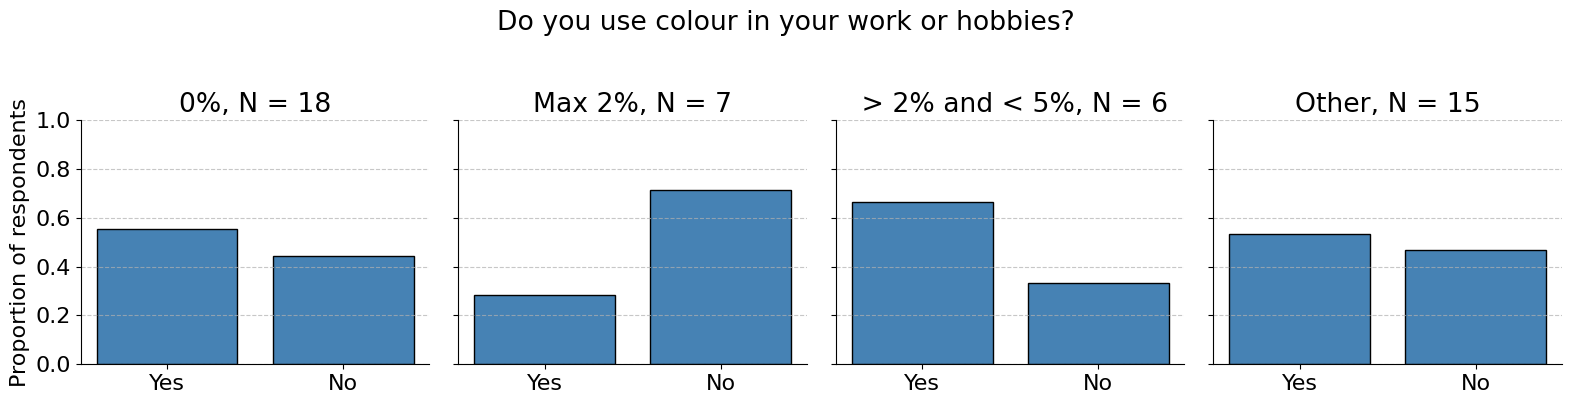

In [58]:
# Labels as they appear in the data (Dutch)
categories_nl = ["Ja, namelijk:", "Nee"]

# Labels for the axis (English)
categories_en = ["Yes", "No"]

# Create 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(1, 4, figsize=(16,4), sharey=True)

# Loop over each subplot together with its dataset and title
for ax, data, title in zip(
    axes,
    [df_totaalblind, df_max2procent, df_2_5procent, df_anders],
    ["0%", "Max 2%", " > 2% and < 5%", "Other"]
):
    # Get the proportion of respondents per answer category
    counts = data["Werk kleur"].value_counts(normalize=True)

    # Reindex using the Dutch labels so the order matches the data
    # (and any missing category is filled with 0)
    counts = counts.reindex(categories_nl, fill_value=0)

    # Plot the bars, but label the x-axis with the English categories
    ax.bar(categories_en, counts.values, color="steelblue", edgecolor="black")

    # Title includes the group name and number of respondents (N)
    ax.set_title(title + f", N = {len(data)}")

    # Subtle horizontal gridlines behind the bars
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim([0,1])  # y-axis runs from 0 to 1 (proportions)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents")

# Overall figure title
plt.suptitle("Do you use colour in your work or hobbies?", y=1.02)
plt.tight_layout()

# Save the figure as a PDF
fig.savefig(fig_folder / 'werkkleur.pdf', bbox_inches='tight')
plt.show()

/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/186399536.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, rotation=90, ha="right", fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/186399536.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, rotation=90, ha="right", fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/186399536.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, rotation=90, ha="right", fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/186399536.py:33: UserWarning: set_ticklabels() should only be used with a fixed num

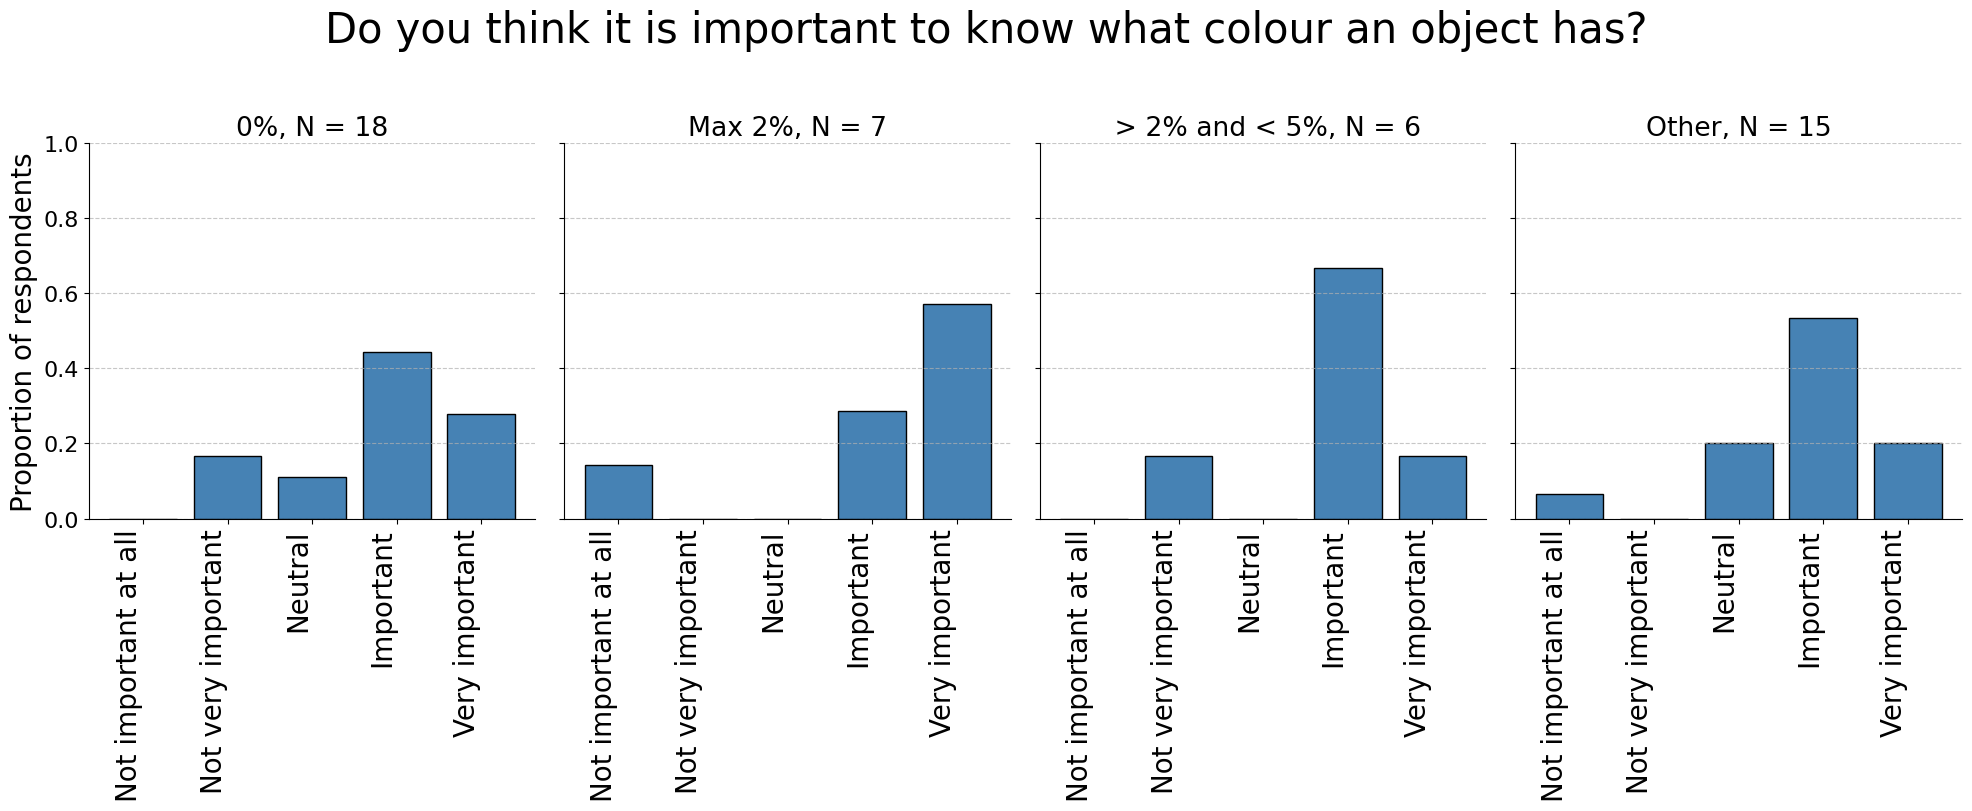

In [59]:
# Labels as they appear in the data (Dutch)
categories_nl = ["Helemaal niet belangrijk", "Niet zo belangrijk", "Neutraal", "Belangrijk", "Heel erg belangrijk"]

# Labels for the axis (English)
categories_en = ["Not important at all", "Not very important", "Neutral", "Important", "Very important"]

# Create 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(1, 4, figsize=(20,8), sharey=True)

# Loop over each subplot together with its dataset and title
for ax, data, title in zip(
    axes,
    [df_totaalblind, df_max2procent, df_2_5procent, df_anders],
    ["0%", "Max 2%", " > 2% and < 5%", "Other"]
):
    # Get the proportion of respondents per answer category
    counts = data["Q61"].value_counts(normalize=True)

    # Reindex using the Dutch labels so the order matches the data
    # (and any missing category is filled with 0)
    counts = counts.reindex(categories_nl, fill_value=0)

    # Plot the bars, but label the x-axis with the English categories
    ax.bar(categories_en, counts.values, color="steelblue", edgecolor="black")

    # Title includes the group name and number of respondents (N)
    ax.set_title(title + f", N = {len(data)}")

    # Subtle horizontal gridlines behind the bars
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Rotate the x-tick labels so the longer category names fit and stay readable
    ax.set_xticklabels(categories_en, rotation=90, ha="right", fontsize=20)

    ax.set_ylim([0,1])  # y-axis runs from 0 to 1 (proportions)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents", fontsize=20)

# Overall figure title
plt.suptitle("Do you think it is important to know what colour an object has?", y=1.02, fontsize=30)
plt.tight_layout()

# Save the figure as a PDF
fig.savefig(fig_folder / 'belangrijkkleur.pdf', bbox_inches='tight')
plt.show()

### Favourite colour

/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/2820274058.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/2820274058.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/2820274058.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories_en, fontsize=20)
/var/folders/m1/c33kty952tg9kmwbgt4f60_40000gn/T/ipykernel_91861/2820274058.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_

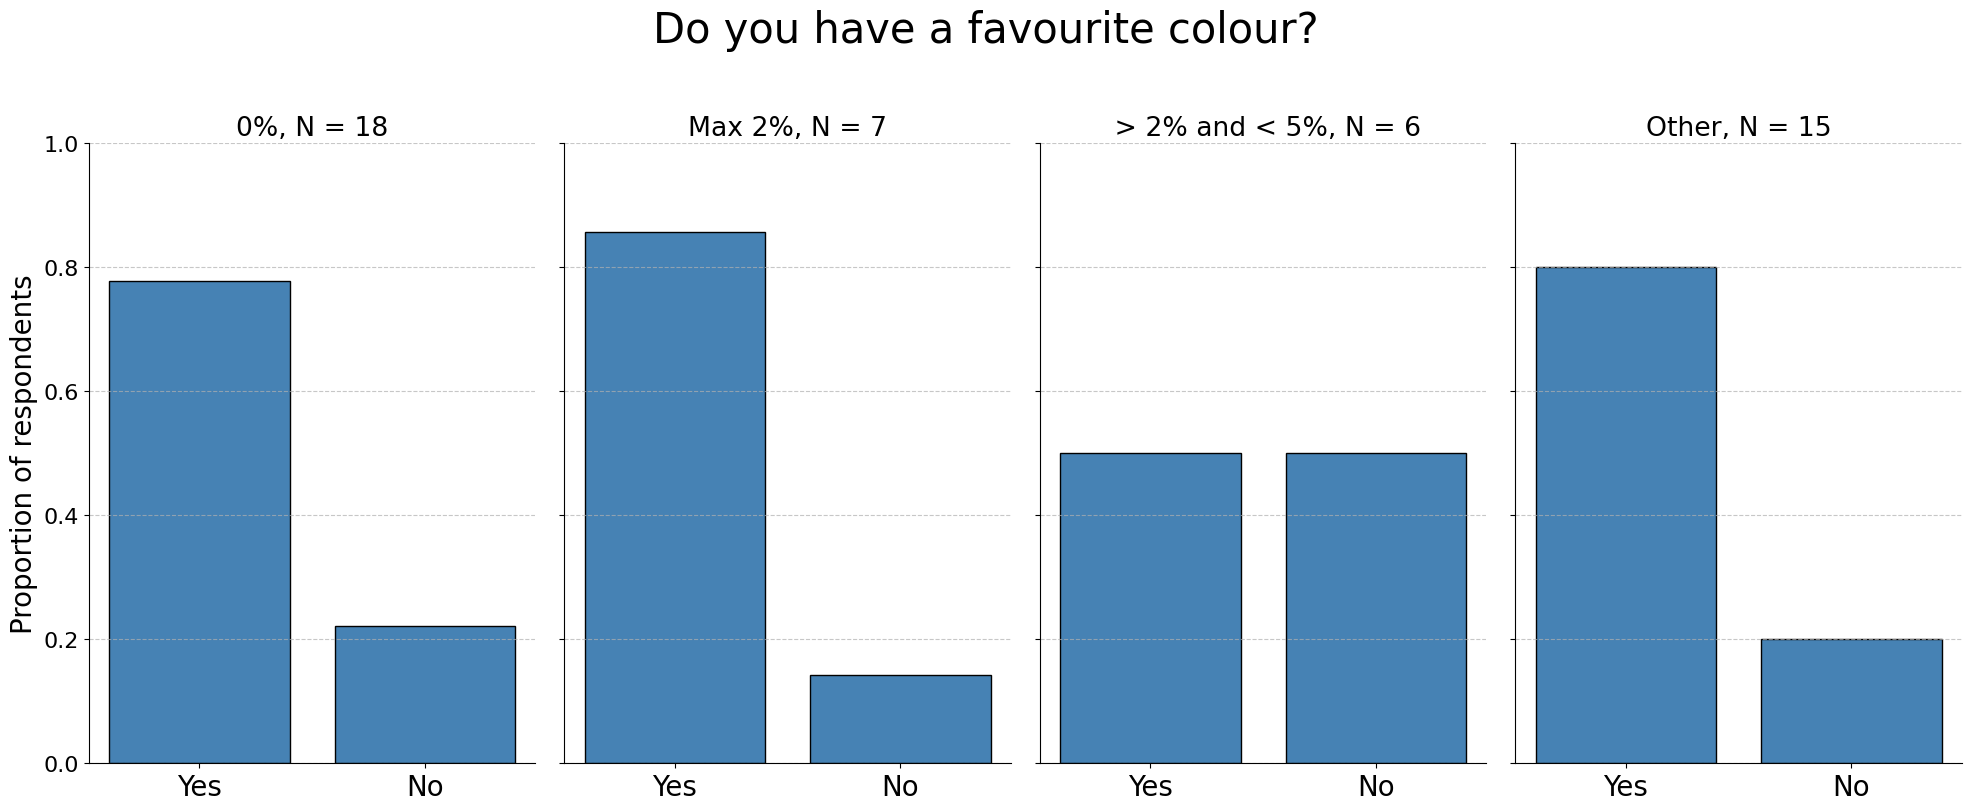

In [60]:
# Labels as they appear in the data (Dutch)
categories_nl = ["Ja", "Nee"]

# Labels for the axis (English)
categories_en = ["Yes", "No"]

# Create 4 subplots side by side, sharing the y-axis
fig, axes = plt.subplots(1, 4, figsize=(20,8), sharey=True)

# Loop over each subplot together with its dataset and title
for ax, data, title in zip(
    axes,
    [df_totaalblind, df_max2procent, df_2_5procent, df_anders],
    ["0%", "Max 2%", " > 2% and < 5%", "Other"]
):
    # Get the proportion of respondents per answer category
    counts = data["Favoriete kleur "].value_counts(normalize=True)

    # Reindex using the Dutch labels so the order matches the data
    # (and any missing category is filled with 0)
    counts = counts.reindex(categories_nl, fill_value=0)

    # Plot the bars, but label the x-axis with the English categories
    ax.bar(categories_en, counts.values, color="steelblue", edgecolor="black")

    # Title includes the group name and number of respondents (N)
    ax.set_title(title + f", N = {len(data)}")

    # Subtle horizontal gridlines behind the bars
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Re-apply the English labels with a larger font size
    ax.set_xticklabels(categories_en, fontsize=20)

    ax.set_ylim([0,1])  # y-axis runs from 0 to 1 (proportions)

# Y-axis label only on the first subplot (since sharey=True)
axes[0].set_ylabel("Proportion of respondents", fontsize=20)

# Overall figure title
plt.suptitle("Do you have a favourite colour?", y=1.02, fontsize=30)
plt.tight_layout()

# Save the figure as a PDF
fig.savefig(fig_folder / 'favorietekleur.pdf', bbox_inches='tight')
plt.show()